# DAG-MCTS Math Primitives Demo

This notebook walks through every core equation of the DAG-MCTS algorithm used in CellHashtag, each grounded in real numbers from a **scanpy pbmc3k** cluster.

**What you'll see:**
- P-UCT selection (with First Play Urgency)
- Priority heuristic $\pi = \text{Relevance} \times \text{Heterogeneity} \times \text{Uncertainty}$
- Soft-Bellman backpropagation (Log-Sum-Exp with temperature $\tau$-scheduling)
- Confidence discounting via DAG in-degree $\lambda_{\text{shared}}$
- 5-component reward with sliding-window normalization
- Potential shaping $N_g$

Reference: `.research_harness_system/docs/methods/dag-mcts-math.md`

In [1]:
import warnings; warnings.filterwarnings("ignore")
import scanpy as sc
import numpy as np
from pathlib import Path

adata_path = Path("../data/pbmc3k.h5ad")
if not adata_path.exists():
    adata_path.parent.mkdir(parents=True, exist_ok=True)
    adata = sc.datasets.pbmc3k()
    adata.write(adata_path)
else:
    adata = sc.read(adata_path)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")
sc.tl.umap(adata)

print(f"cells={adata.n_obs}  genes={adata.n_vars}  clusters={adata.obs['leiden'].nunique()}")
adata.obs['leiden'].value_counts().head()

cells=2700  genes=13714  clusters=5


leiden
0    1285
1     681
2     371
3     350
4      13
Name: count, dtype: int64

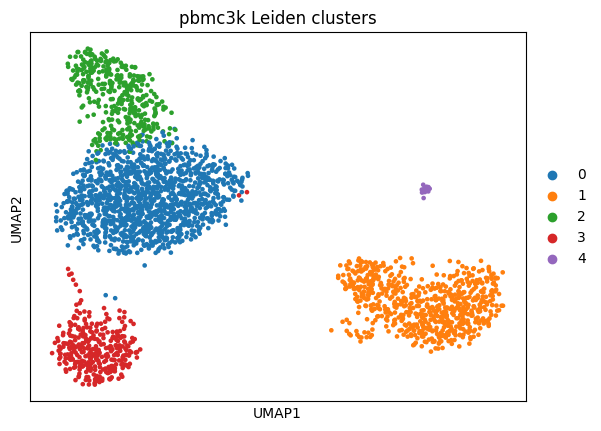

In [2]:
import matplotlib.pyplot as plt
sc.pl.umap(adata, color="leiden", legend_loc="right margin", title="pbmc3k Leiden clusters", show=False)
plt.show()

---
## 1. Cluster statistics — the input to every equation

We pick **one target cluster** to drive every equation below. Pull silhouette + heterogeneity + marker genes.


In [3]:
import sklearn.metrics as skm

X = adata.obsm["X_pca"]
labels = adata.obs["leiden"].astype(str).values
sil_per_cell = skm.silhouette_samples(X, labels)
adata.obs["silhouette"] = sil_per_cell

cluster_stats = {}
for c in sorted(set(labels)):
    mask = labels == c
    stats = {
        "n": int(mask.sum()),
        "silhouette": float(sil_per_cell[mask].mean()),
        "het": 1.0 - float(sil_per_cell[mask].mean()),
        "conf": float(max(sil_per_cell[mask].mean(), 0.1)),
    }
    cluster_stats[c] = stats

target_c = max(cluster_stats, key=lambda c: cluster_stats[c]["het"])
print("Target cluster =", target_c)
print(cluster_stats[target_c])

sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon", n_genes=10)
markers = adata.uns["rank_genes_groups"]["names"][target_c][:10].tolist()
print("Top markers:", markers)

Target cluster = 2
{'n': 371, 'silhouette': 0.022212665528059006, 'het': 0.977787334471941, 'conf': 0.1}


Top markers: ['NKG7', 'CST7', 'GZMA', 'CTSW', 'B2M', 'HLA-C', 'CCL5', 'HLA-A', 'PRF1', 'HLA-B']


---
## 2. Priority heuristic $\pi$

$$\pi(\text{cluster}) = \text{Relevance} \times \text{Heterogeneity} \times \text{Uncertainty}$$

| Factor | Definition |
|---|---|
| Relevance $R$ | 1.0 if cluster label intersects `target_lineages`, else 0.3 |
| Heterogeneity $H$ | $1 - \text{silhouette}$ (high = messy, worth exploring) |
| Uncertainty $U$ | $1 - \text{current confidence}$ |


In [4]:
from cellhashtag.core.dag_mcts import priority

cluster_info = {
    "label": f"cluster_{target_c}",
    "heterogeneity": cluster_stats[target_c]["het"],
    "confidence": cluster_stats[target_c]["conf"],
}
research_context = {"target_lineages": ["t cell", "b cell"]}

pi = priority(cluster_info, research_context)
R = 0.3
H = cluster_stats[target_c]["het"]
U = 1.0 - cluster_stats[target_c]["conf"]

print(f"Relevance     R = {R:.3f}")
print(f"Heterogeneity H = {H:.3f}")
print(f"Uncertainty   U = {U:.3f}")
print(f"Priority pi = R * H * U = {R*H*U:.3f}")
print(f"(api priority() returns {pi:.3f})")

Relevance     R = 0.300
Heterogeneity H = 0.978
Uncertainty   U = 0.900
Priority pi = R * H * U = 0.264
(api priority() returns 0.264)


---
## 3. First Play Urgency (FPU)

Unvisited nodes have no $Q$ yet. Plain UCB would over-explode or under-explore them. FPU injects a **priority-aware** prior:

$$\text{FPU}(c) = \begin{cases}
V_{\text{root}} + \delta & \text{if } \pi(c) \ge \theta_{\text{high}} \\
V_{\text{root}} - \delta & \text{if } \pi(c) < \theta_{\text{low}} \\
V_{\text{root}} & \text{otherwise}
\end{cases}$$

Visited nodes fall back to their $Q$-value.


In [5]:
from cellhashtag.core.dag_mcts import DAGNode, fpu

node = DAGNode(node_id="demo", state_hash="h_demo", visits=0, q_value=0.0)
V_root = 0.5
delta = 0.5
theta_high, theta_low = 0.7, 0.3

print("Unvisited node (visits=0):")
for pi_val, label in [(0.8, "high priority"), (0.5, "medium priority"), (0.2, "low priority")]:
    v = fpu(node, V_root, delta, pi_val, theta_high, theta_low)
    print(f"  pi={pi_val} ({label:14s}) -> FPU = {v:.2f}")

node.visits = 3
node.q_value = 0.72
v_visited = fpu(node, V_root, delta, 0.9, theta_high, theta_low)
print(f"Visited node (visits={node.visits}, Q={node.q_value}): FPU = {v_visited:.2f}  (returns Q)")

Unvisited node (visits=0):
  pi=0.8 (high priority ) -> FPU = 1.00
  pi=0.5 (medium priority) -> FPU = 0.50
  pi=0.2 (low priority  ) -> FPU = 0.00
Visited node (visits=3, Q=0.72): FPU = 0.72  (returns Q)


---
## 4. P-UCT selection

At each internal node, pick the child with highest:

$$\text{P-UCT}(c) = \text{FPU}(c) + c_{\text{puct}} \cdot P(c) \cdot \frac{\sqrt{N_{\text{parent}}}}{1 + N_c}$$

- $P(c)$ = prior from LLM action weights (normalized, ε-tail)
- $c_{\text{puct}}$ = exploration constant (default 1.5)
- $N$ = visit counts


In [6]:
import math

N_parent = 50
cpuct = 1.5
children = [
    {"N": 20, "Q": 0.62, "P": 0.5, "visits": 20},
    {"N": 10, "Q": 0.45, "P": 0.3, "visits": 10},
    {"N":  0, "Q": 0.0, "P": 0.2, "visits": 0, "pi": 0.8},
]

header = f"{'child':>8} {'N':>4} {'Q':>5} {'P':>5} {'FPU':>6} {'expl':>6} {'P-UCT':>7}"
print(header)
print("-" * 48)
for i, c in enumerate(children):
    fpu_v = V_root + delta if c["visits"] == 0 else c["Q"]
    exploration = cpuct * c["P"] * math.sqrt(N_parent) / (1 + c["N"])
    score = fpu_v + exploration
    print(f"child{i}  N={c['N']:>2}  Q={c['Q']:.2f}  P={c['P']:.2f}  FPU={fpu_v:.2f}  expl={exploration:.3f}  P-UCT={score:.3f}")

   child    N     Q     P    FPU   expl   P-UCT
------------------------------------------------
child0  N=20  Q=0.62  P=0.50  FPU=0.62  expl=0.253  P-UCT=0.873
child1  N=10  Q=0.45  P=0.30  FPU=0.45  expl=0.289  P-UCT=0.739
child2  N= 0  Q=0.00  P=0.20  FPU=1.00  expl=2.121  P-UCT=3.121


---
## 5. Temperature $\tau$ at depth

Soft-Bellman smooths the max operator with a temperature that **decays with depth**, so deeper nodes commit harder:

$$\tau_d = \frac{\tau_0}{1 + \gamma \cdot d}$$

Default: $\tau_0 = 1.0$, $\gamma = 0.25$.


In [7]:
from cellhashtag.core.dag_mcts import temperature_at_depth

tau0, gamma = 1.0, 0.25
print(f"{'depth':>5} {'tau':>6}")
for d in range(8):
    tau = temperature_at_depth(d, tau0, gamma)
    print(f"{d:>5} {tau:>6.3f}")

depth    tau
    0  1.000
    1  0.800
    2  0.667
    3  0.571
    4  0.500
    5  0.444
    6  0.400
    7  0.364


---
## 6. Soft-Bellman value $V$ (Log-Sum-Exp)

For a parent with children $c_1 \dots c_k$, the parent's value is a **smooth maximum**:

$$V(n) = \tau_d \cdot \log\!\left(\sum_{c} w_c \cdot \exp\!\left(\frac{Q(c)}{\tau_d}\right)\right)$$

where $w_c = \frac{\max(N_c, 1)}{\sum_j \max(N_j, 1)}$. As $\tau \to 0$, this converges to $\max_c Q(c)$.


In [8]:
from cellhashtag.core.dag_mcts import soft_bellman_v, TranspositionTable

tt = TranspositionTable()
parent = DAGNode(node_id="p", state_hash="h_p", q_value=0.0)
child_a = DAGNode(node_id="a", state_hash="h_a", visits=20, q_value=0.8, parents=["p"])
child_b = DAGNode(node_id="b", state_hash="h_b", visits= 5, q_value=0.5, parents=["p"])
child_c = DAGNode(node_id="c", state_hash="h_c", visits=10, q_value=0.95, parents=["p"])
parent.children = ["h_a", "h_b", "h_c"]
for n in [parent, child_a, child_b, child_c]:
    tt.store(n)

print("children: a(Q=0.80, N=20), b(Q=0.50, N=5), c(Q=0.95, N=10)")
print(f"hard max = {max(0.80, 0.50, 0.95):.3f}")
for tau in [2.0, 1.0, 0.5, 0.2]:
    v = soft_bellman_v(parent, tt, tau=tau)
    print(f"Soft-Bellman(tau={tau}) = {v:.3f}")
print("(tau down-arrow => smooth max approaches hard max)")

children: a(Q=0.80, N=20), b(Q=0.50, N=5), c(Q=0.95, N=10)
hard max = 0.950
Soft-Bellman(tau=2.0) = 0.805
Soft-Bellman(tau=1.0) = 0.809
Soft-Bellman(tau=0.5) = 0.817
Soft-Bellman(tau=0.2) = 0.838
(tau down-arrow => smooth max approaches hard max)


---
## 7. Confidence discount $\lambda_{\text{shared}}$

DAG nodes with multiple parents share evidence. Discount to avoid double-counting:

$$\lambda_{\text{shared}} = \frac{1}{1 + \alpha \cdot (|\text{Parents}| - 1)}$$

Plus hallucination risk weight $\lambda_{\text{halluc}} \in \{1.0, 0.6, 0.2\}$ for risk $\in \{\text{low, medium, high}\}$.


In [9]:
from cellhashtag.core.dag_mcts import shared_discount

alpha = 0.3
print(f"{'#parents':>10} {'lambda_shared':>14}")
for k in [1, 2, 3, 5, 10]:
    n = DAGNode(node_id="x", state_hash=f"h_{k}", parents=[f"p{i}" for i in range(k)])
    lam = shared_discount(n, alpha)
    print(f"{k:>10} {lam:>14.3f}")

n3 = DAGNode(node_id="x", state_hash="h", parents=["p1", "p2", "p3"])
lam3 = shared_discount(n3, 0.3)
print(f"hallucination risk weights: low=1.0  medium=0.6  high=0.2")
print(f"combined example (3 parents, medium risk): lambda = {lam3:.3f} * 0.6 = {lam3 * 0.6:.3f}")

  #parents  lambda_shared
         1          1.000
         2          0.769
         3          0.625
         5          0.455
        10          0.270
hallucination risk weights: low=1.0  medium=0.6  high=0.2
combined example (3 parents, medium risk): lambda = 0.625 * 0.6 = 0.375


---
## 8. 5-component reward

Every evaluation produces:

$$r_{\text{raw}} = \sum_i w_i \cdot s_i - \beta \cdot f$$

| Component | Weight | Meaning |
|---|---|---|
| purity | 0.25 | cluster internal homogeneity |
| specificity | 0.20 | marker exclusivity vs other clusters |
| context | 0.20 | tissue ontology consistency |
| lats | 0.20 | reflection self-assessment |
| known_marker | 0.15 | CellWiki canonical overlap |
| fragmentation $f$ | penalty | over-splitting penalty |

Then sliding-window normalization + potential shaping:

$$r_{\text{final}} = r_{\text{norm}} + \gamma \cdot (N_g(s') - N_g(s))$$


In [10]:
from cellhashtag.core.reward import compute_reward, SlidingWindowNormalizer, final_reward, potential, ClusterStats

raw = compute_reward(purity=0.78, specificity=0.65, context_score=0.82, lats_score=0.70,
                     known_marker_score=0.55, overfragmentation_penalty=0.05)
print("raw breakdown:")
print(f"  purity         {raw.purity:.3f}")
print(f"  specificity    {raw.specificity:.3f}")
print(f"  context        {raw.context:.3f}")
print(f"  lats           {raw.lats:.3f}")
print(f"  known_marker   {raw.known_marker:.3f}")
print(f"  weighted sum   {raw.raw:.3f}")
print(f"  final (pre-norm) {raw.final:.3f}")

norm = SlidingWindowNormalizer()
for i in range(5):
    sample = compute_reward(purity=0.5 + 0.05 * i, specificity=0.5, context_score=0.5,
                            lats_score=0.5, known_marker_score=0.5)
    norm.push(sample.raw)
normalized = norm.normalize(raw.raw)
print(f"window stats     = {norm.stats()}")
print(f"z-score of raw   = {normalized:.3f}")

clusters_now = [ClusterStats(label="0", silhouette=0.5, marker_coherence=0.5)]
clusters_next = [ClusterStats(label="0", silhouette=0.7, marker_coherence=0.6)]
Ng_now = potential(clusters_now)
Ng_next = potential(clusters_next)
r_final = final_reward(raw, normalized, Ng_next, Ng_now)
print(f"Ng(now)={Ng_now:.3f}  Ng(next)={Ng_next:.3f}  shaping_delta={Ng_next - Ng_now:.3f}")
print(f"r_final = {r_final.final:.3f}")

raw breakdown:
  purity         0.780
  specificity    0.650
  context        0.820
  lats           0.700
  known_marker   0.550
  weighted sum   0.661
  final (pre-norm) 0.000
window stats     = {'mu': 0.525, 'sigma': 0.017677669529663674, 'n': 5}
z-score of raw   = 7.722
Ng(now)=0.480  Ng(next)=0.630  shaping_delta=0.150
r_final = 7.840


---
## 9. Putting it together — one backpropagation step

Full update for one node on the leaf-to-root path:

$$\Delta = r_{\text{immediate}} + \lambda_{\text{shared}} \cdot \lambda_{\text{halluc}} \cdot V_{\text{successor}} - Q(n)$$
$$Q(n) \mathrel{+}= \frac{\Delta}{\max(\text{visits}, 1)}, \quad \text{visits} \mathrel{+}= 1$$


In [11]:
from cellhashtag.core.dag_mcts import backpropagate

tt = TranspositionTable()
root = DAGNode(node_id="root", state_hash="h_root", q_value=0.3, visits=5)
mid  = DAGNode(node_id="mid",  state_hash="h_mid",  q_value=0.4, visits=3, parents=["h_root"])
leaf = DAGNode(node_id="leaf", state_hash="h_leaf", q_value=0.0, visits=0, parents=["h_mid"])
root.children = ["h_mid"]
mid.children = ["h_leaf"]
for n in [root, mid, leaf]:
    tt.store(n)

r_immediate = 0.82
print(f"BEFORE: root Q={root.q_value:.3f} N={root.visits}  |  mid Q={mid.q_value:.3f} N={mid.visits}  |  leaf Q={leaf.q_value:.3f} N={leaf.visits}")
backpropagate(leaf, tt, immediate_reward=r_immediate, tau0=1.0, alpha=0.3)
print(f"AFTER : root Q={root.q_value:.3f} N={root.visits}  |  mid Q={mid.q_value:.3f} N={mid.visits}  |  leaf Q={leaf.q_value:.3f} N={leaf.visits}")
print("(Every node on path got visits += 1 and Q updated toward r_immediate + discounted successor value.)")

BEFORE: root Q=0.300 N=5  |  mid Q=0.400 N=3  |  leaf Q=0.000 N=0
AFTER : root Q=0.539 N=6  |  mid Q=0.915 N=4  |  leaf Q=1.640 N=1
(Every node on path got visits += 1 and Q updated toward r_immediate + discounted successor value.)


---
## 10. Summary of all equations

| # | Equation | Purpose |
|---|---|---|
| 1 | $\pi = R \cdot H \cdot U$ | Priority heuristic |
| 2 | FPU piecewise | First Play Urgency for unvisited nodes |
| 3 | P-UCT | Selection with prior + exploration |
| 4 | $\tau_d = \tau_0 / (1+\gamma d)$ | Temperature schedule |
| 5 | Soft-Bellman V | Smooth max over children |
| 6 | $\lambda_{\text{shared}} = 1/(1+\alpha(k-1))$ | Confidence discount by in-degree |
| 7 | $r = \sum w_i s_i - \beta f$ | 5-component reward |
| 8 | $r_{\text{final}} = r_{\text{norm}} + \gamma(N_g' - N_g)$ | Potential shaping |
| 9 | $\Delta = r + \lambda V - Q$ | Q update per node |

Next: `02_dag_mcts_workflow.ipynb` runs the full loop on this cluster.
